In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import itertools
from copy import deepcopy

RANDOM_STATE = 42

In [52]:
def to_df(dataset_split):
    return dataset_split.to_pandas()


def infer_task_type(y: pd.Series) -> str:
    if not pd.api.types.is_numeric_dtype(y):
        return "classification"
    nunique = y.nunique(dropna=True)
    if nunique <= 20:
        return "classification"
    return "regression"


def smart_stratify(y: pd.Series, task: str, n_bins: int = 10, min_bin: int = 2):


    y = pd.Series(y)

    if task == "classification":
        vc = y.value_counts(dropna=False)
        return y if (len(vc) > 1 and vc.min() >= 2) else None

    try:
        bins = pd.qcut(y, q=n_bins, duplicates="drop")
        vc = bins.value_counts(dropna=False)
        return bins if (len(vc) > 1 and vc.min() >= min_bin) else None
    except Exception:
        return None


def split_60_20_20(X, y, task: str, random_state=42):

    strat1 = smart_stratify(y, task=task)
    X_trval, X_test, y_trval, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=strat1
    )

    strat2 = smart_stratify(y_trval, task=task)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_trval, y_trval, test_size=0.25, random_state=random_state, stratify=strat2
    )
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def get_preprocessor(X: pd.DataFrame):
    numeric_features = X.select_dtypes(include=[np.number]).columns.to_list()
    categorical_features = [c for c in X.columns if c not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop"
    )
    return preprocessor, numeric_features, categorical_features


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def maybe_rmsle(y_true, y_pred):

    if (np.min(y_true) < 0) or (np.min(y_pred) < 0):
        return None
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


def eval_regression(y_true, y_pred):
    out = {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse(y_true, y_pred),
        "r2": float(r2_score(y_true, y_pred))
    }
    rmsle_val = maybe_rmsle(np.asarray(y_true), np.asarray(y_pred))
    if rmsle_val is not None:
        out["rmsle"] = rmsle_val
    return out


def plot_regression(y_true, y_pred, title_prefix="Model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure()
    plt.scatter(y_true, y_pred)
    mn, mx = float(np.min(y_true)), float(np.max(y_true))
    plt.plot([mn, mx], [mn, mx])
    plt.title(f"{title_prefix}: y_pred vs y")
    plt.xlabel("y")
    plt.ylabel("y_pred")
    plt.tight_layout()
    plt.show()

    residuals = y_true - y_pred
    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.title(f"{title_prefix}: residuals vs y_pred")
    plt.xlabel("y_pred")
    plt.ylabel("residuals (y - y_pred)")
    plt.tight_layout()
    plt.show()


def choose_best_model(results: dict, task: str, key_metric: str = None):

    if task == "classification":
        metric = key_metric or "f1_macro"
        best_name = max(results.keys(), key=lambda k: results[k][metric])
        return best_name, metric, "max"
    else:
        metric = key_metric or "rmse"
        best_name = min(results.keys(), key=lambda k: results[k][metric])
        return best_name, metric, "min"


def run_grid(models: dict, preprocessor, X_train, y_train, task: str, scoring: str, param_grids: dict):

    rows = []
    for name, base_model in models.items():
        grid = param_grids.get(name, None)
        if not grid:
            pipe = Pipeline([("prep", preprocessor), ("model", clone(base_model))])
            scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring=scoring)
            rows.append({"model": name, "cv_score": float(np.mean(scores))})
            continue

        keys = list(grid.keys())
        values = list(grid.values())

        for combo in itertools.product(*values):
            params = dict(zip(keys, combo))
            pipe = Pipeline([("prep", preprocessor), ("model", clone(base_model))])
            pipe.set_params(**params)

            scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring=scoring)
            row = {"model": name, "cv_score": float(np.mean(scores))}
            row.update(params)
            rows.append(row)

    df = pd.DataFrame(rows).sort_values("cv_score", ascending=False if "f1" in scoring or "r2" in scoring else True)
    best_row = df.iloc[0]
    return df, best_row


def drop_one_feature_importance(best_model, preprocessor_builder, X_train, y_train, X_valid, y_valid, task: str, metric: str):

    base_pipe = Pipeline([("prep", preprocessor_builder(X_train)[0]), ("model", deepcopy(best_model))])
    base_pipe.fit(X_train, y_train)
    base_pred = base_pipe.predict(X_valid)

    if task == "classification":
        base_score = float(f1_score(y_valid, base_pred, average="macro"))
        better_is = "higher"
    else:
        met = eval_regression(y_valid, base_pred)
        base_score = float(met.get(metric))
        better_is = "lower" if metric in ("mae", "rmse", "rmsle") else "higher"

    rows = []
    for col in X_train.columns:
        Xtr_d = X_train.drop(columns=[col])
        Xva_d = X_valid.drop(columns=[col])

        preproc_d, _, _ = preprocessor_builder(Xtr_d)
        pipe_d = Pipeline([("prep", preproc_d), ("model", deepcopy(best_model))])
        pipe_d.fit(Xtr_d, y_train)
        pred_d = pipe_d.predict(Xva_d)

        if task == "classification":
            score_d = float(f1_score(y_valid, pred_d, average="macro"))
        else:
            met_d = eval_regression(y_valid, pred_d)
            score_d = float(met_d.get(metric))

        delta = score_d - base_score
        rows.append({"dropped": col, metric: score_d, "delta_vs_base": delta})

    df = pd.DataFrame(rows)

    if better_is == "higher":
        df = df.sort_values(metric, ascending=True)
    else:
        df = df.sort_values(metric, ascending=False)

    return base_score, df

In [53]:
# ========================
# Шаг 2.1 Выбор датасета
# ========================
DATASET_NAME = "scikit-learn/adult-census-income"
#DATASET_NAME = input("Введите датасет: ")
#if DATASET_NAME == "":
#    print("Датасет не выбран. Использую SIH/palmer-penguins...")
#    DATASET_NAME = "SIH/palmer-penguins"
DATA_FILES = ""
#DATA_FILES = input("Введите data file: ")
if DATA_FILES == "":
    ds = load_dataset(DATASET_NAME)
else:
    ds = load_dataset(DATASET_NAME, data_files=DATA_FILES)
#ds = load_dataset("inria-soda/tabular-benchmark", "reg_cat_abalone")
print(ds)

if "train" in ds:
    df = to_df(ds["train"])
else:
    df = to_df(ds[list(ds.keys())[0]])

print("\nData shape:", df.shape)
print("Columns:", list(df.columns))

DatasetDict({
    train: Dataset({
        features: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income'],
        num_rows: 32561
    })
})

Data shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [54]:
# ===========================
# Шаг 2.2 Формулировка задачи
# ===========================
#TARGET = input("\nВыберите целевую колокну: ")
TARGET = "income"
#if TARGET == "":
#    print("Колонка не выбрана. Использую species..")
#    TARGET = "species"

assert TARGET in df.columns, f"TARGET='{TARGET}' не найден в колонках: {list(df_train.columns)}"

df = df.dropna(subset=[TARGET]).copy()



=== Head ===
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18 

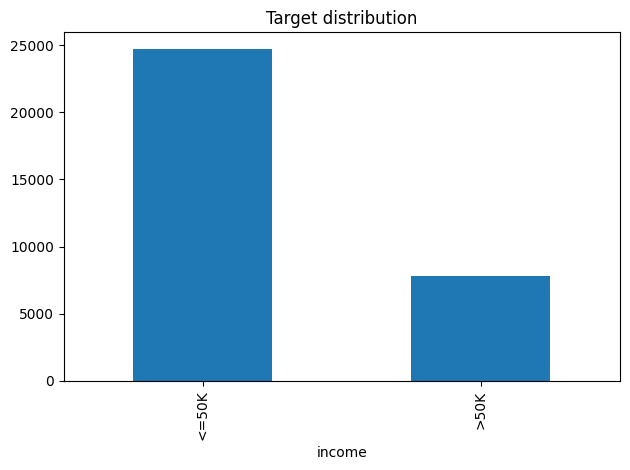

In [55]:
# ===========================
# Шаг 2.3 EDA
# ===========================

print("\n=== Head ===")
print(df.head())

print("\n=== Info ===")
print(df.info())

print("\n=== Missing values (count) ===")
print(df.isna().sum().sort_values(ascending=False).head(20))

y_full = df[TARGET]
task = infer_task_type(y_full)
print("\nТип задачи:", task)

if task == "classification":
    print("\n=== Target distribution ===")
    print(y_full.value_counts(dropna=False))
    plt.figure()
    y_full.value_counts().plot(kind="bar")
    plt.title("Target distribution")
    plt.tight_layout()
    plt.show()
else:
    print("\n=== Target stats ===")
    print(y_full.describe())


Numeric features: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


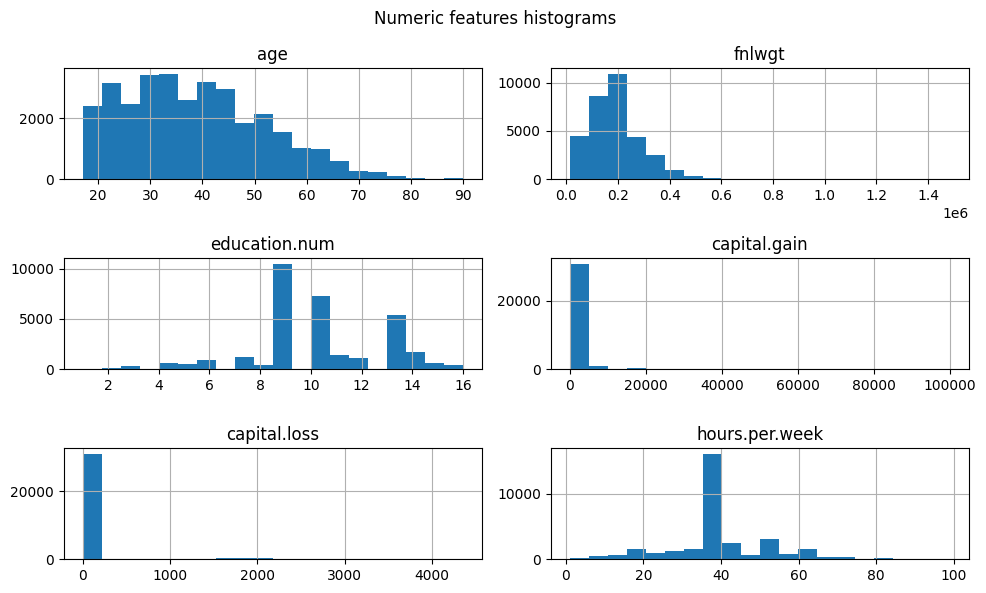

Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

Split sizes:
  train: (19536, 14) valid: (6512, 14) test: (6513, 14)


In [56]:
# ============================
# Шаг 2.4 Обработка данных
# ============================

X_full = df.drop(columns=[TARGET])
y_full = df[TARGET]

def preprocessor_builder(X):
    return get_preprocessor(X)

preprocessor, numeric_features, categorical_features = get_preprocessor(X_full)
print("\nNumeric features:", numeric_features)

numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET in numeric_cols_all:
    numeric_cols_all.remove(TARGET)

if len(numeric_cols_all) > 0:
    df[numeric_cols_all].hist(bins=20, figsize=(10, 6))
    plt.suptitle("Numeric features histograms")
    plt.tight_layout()
    plt.show()

print("Categorical features:", categorical_features)

X_train, X_valid, X_test, y_train, y_valid, y_test = split_60_20_20(
    X_full, y_full, task=task, random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("  train:", X_train.shape, "valid:", X_valid.shape, "test:", X_test.shape)

if task == "regression":
    print("\n=== Baselines (regression) ===")
    y_mean = float(np.mean(y_train))
    y_median = float(np.median(y_train))

    pred_mean = np.full(shape=len(y_valid), fill_value=y_mean, dtype=float)
    pred_median = np.full(shape=len(y_valid), fill_value=y_median, dtype=float)

    m_mean = eval_regression(y_valid, pred_mean)
    m_median = eval_regression(y_valid, pred_median)

    baseline_df = pd.DataFrame([
        {"model": "BaselineMean", **m_mean},
        {"model": "BaselineMedian", **m_median},
    ])
    print(baseline_df)

In [57]:
# =========================
# Шаг 3 Модели
# =========================

print("\nВыберите модели для обучения (через запятую). Доступно:")
if task == "classification":
    print("  1 - LogReg")
    print("  2 - KNN")
    print("  3 - DecisionTree")
    print("  4 - RandomForest")
else:
    print("  1 - Linear-ish (Ridge=L2, Lasso=L1)")
    print("  2 - KNNRegressor")
    print("  3 - DecisionTreeRegressor")
    print("  4 - RandomForestRegressor")

print("Примеры ввода: 1  |  1,2  |  2,4")
#choice = input("Ваш выбор: ").strip()
choice = "1,4"
selected = set(choice.replace(";", ",").replace(" ", ",").split(",")) if choice else {"1", "4"}

models = {}

if task == "classification":
    if "1" in selected: models["LogReg"] = LogisticRegression(max_iter=2000, solver="lbfgs")
    if "2" in selected: models["KNN"] = KNeighborsClassifier(n_neighbors=7)
    if "3" in selected: models["DecisionTree"] = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)
    if "4" in selected: models["RandomForest"] = RandomForestClassifier( n_estimators=300, random_state=RANDOM_STATE)
else:
    if "1" in selected:
        models["Ridge_L2"] = Ridge(alpha=1.0, random_state=RANDOM_STATE)
        models["Lasso_L1"] = Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=20000)
    if "2" in selected: models["KNNReg"] = KNeighborsRegressor(n_neighbors=7)
    if "3" in selected: models["DecisionTreeReg"] = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=10)
    if "4" in selected: models["RandomForestReg"] = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)


if len(models) == 0:
    if task == "classification":
        models = {"LogReg": LogisticRegression(max_iter=2000, solver="lbfgs")}
    else:
        models = {"Ridge_L2": Ridge(alpha=1.0), "Lasso_L1": Lasso(alpha=0.001, max_iter=20000)}

results = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_valid)

    print(f"\n=== Модель: {name} ===")
    if task == "classification":
        acc = float(accuracy_score(y_valid, preds))
        f1m = float(f1_score(y_valid, preds, average="macro"))
        results[name] = {"accuracy": acc, "f1_macro": f1m, "pipe": pipe, "preds": preds}
        print("Точность (Accuracy):", acc)
        print("F1-macro:", f1m)
    else:
        met = eval_regression(y_valid, preds)
        results[name] = {**met, "pipe": pipe, "preds": preds}
        print("MAE:", met["mae"])
        print("RMSE:", met["rmse"])
        print("R2:", met["r2"])
        if "rmsle" in met:
            print("RMSLE:", met["rmsle"])

print("\n=== Сравнение моделей ===")
if task == "classification":
    summary_df = pd.DataFrame({k: {"accuracy": v["accuracy"], "f1_macro": v["f1_macro"]} for k, v in results.items()}).T
    print(summary_df.sort_values("f1_macro", ascending=False))
else:
    summary_df = pd.DataFrame({k: {"mae": v["mae"], "rmse": v["rmse"], "r2": v["r2"]} for k, v in results.items()}).T
    print(summary_df.sort_values("rmse", ascending=True))

best_name, best_metric, direction = choose_best_model(results, task=task, key_metric=("f1_macro" if task=="classification" else "rmse"))
best_pipe = results[best_name]["pipe"]
best_preds = results[best_name]["preds"]
print(f"\nЛучшая модель по метрике {best_metric} ({direction}): {best_name}")


Выберите модели для обучения (через запятую). Доступно:
  1 - LogReg
  2 - KNN
  3 - DecisionTree
  4 - RandomForest
Примеры ввода: 1  |  1,2  |  2,4

=== Модель: LogReg ===
Точность (Accuracy): 0.8464373464373465
F1-macro: 0.776542293969044

=== Модель: RandomForest ===
Точность (Accuracy): 0.8576474201474201
F1-macro: 0.7952445684111105

=== Сравнение моделей ===
              accuracy  f1_macro
RandomForest  0.857647  0.795245
LogReg        0.846437  0.776542

Лучшая модель по метрике f1_macro (max): RandomForest



=== Отчёт по классификации (valid) ===
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4944
        >50K       0.74      0.63      0.68      1568

    accuracy                           0.86      6512
   macro avg       0.81      0.78      0.80      6512
weighted avg       0.85      0.86      0.85      6512



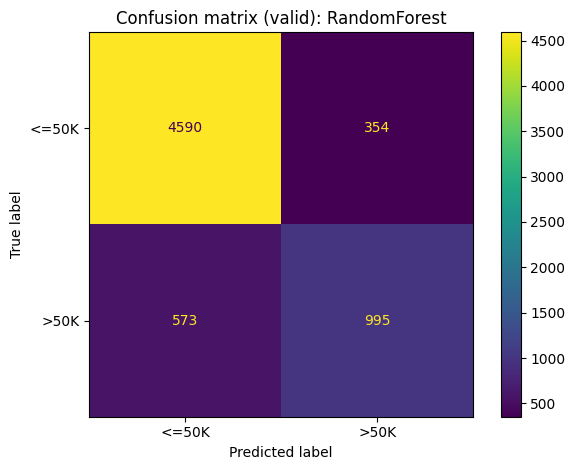

In [58]:
# ======================
# Шаг 4 Оценка качества
# ======================

if task == "classification":
    print("\n=== Отчёт по классификации (valid) ===")
    print(classification_report(y_valid, best_preds))

    cm = confusion_matrix(y_valid, best_preds, labels=np.unique(y_valid))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_valid))
    disp.plot(values_format="d")
    plt.title(f"Confusion matrix (valid): {best_name}")
    plt.tight_layout()
    plt.show()
else:
    print("\n=== Графики регрессии (valid) ===")
    plot_regression(y_valid, best_preds, title_prefix=f"{best_name} (valid)")

In [59]:
# ====================
# Шаг 5 Эксперименты
# ====================

print("\n=== Подбор гиперпараметров (Grid + CV только по train) ===")

if task == "classification":
    scoring = "f1_macro"
    param_grids = {
        "LogReg": {"model__C": [0.1, 1.0, 10.0], "model__solver": ["lbfgs"]},
        "KNN": {"model__n_neighbors": [3, 5, 7, 11], "model__weights": ["uniform", "distance"]},
        "DecisionTree": {"model__max_depth": [None, 3, 5, 7, 10], "model__min_samples_split": [2, 5, 10]},
        "RandomForest": {"model__n_estimators": [100, 300], "model__max_depth": [None, 10], "model__min_samples_split": [2, 5]},
    }
else:
    scoring = "neg_root_mean_squared_error"
    param_grids = {
        "Ridge_L2": {"model__alpha": [0.1, 1.0, 10.0]},
        "Lasso_L1": {"model__alpha": [0.0005, 0.001, 0.01]},
        "KNNReg": {"model__n_neighbors": [3, 5, 7, 11], "model__weights": ["uniform", "distance"]},
        "DecisionTreeReg": {"model__max_depth": [None, 5, 10], "model__min_samples_split": [2, 5, 10]},
        "RandomForestReg": {"model__n_estimators": [100, 300], "model__max_depth": [None, 10], "model__min_samples_split": [2, 5]},
    }

grid_df, best_row = run_grid(models, preprocessor, X_train, y_train, task=task, scoring=scoring, param_grids=param_grids)
print(grid_df.head(15))

best_model_name = best_row["model"]
best_params = {}

for k in best_row.index:
    if str(k).startswith("model__") and pd.notna(best_row[k]):
        v = best_row[k]

        if isinstance(v, np.integer):
            v = int(v)
        elif isinstance(v, np.floating):
            if float(v).is_integer():
                v = int(v)
            else:
                v = float(v)

        best_params[k] = v

print("\nЛучшая модель по CV:", best_model_name)
print("Лучшие параметры:", best_params)
print("Лучший cv_score:", float(best_row["cv_score"]))

tuned_model = clone(models[best_model_name])
tuned_pipe = Pipeline([("prep", preprocessor), ("model", tuned_model)])
tuned_pipe.set_params(**best_params)
tuned_pipe.fit(X_train, y_train)

print("\n=== Кросс-валидация (5-fold) на train ===")

if task == "classification":
    cv_scoring = "f1_macro"
else:
    cv_scoring = "neg_root_mean_squared_error"
cv_scores = cross_val_score(tuned_pipe, X_train, y_train, cv=5, scoring=cv_scoring)

if task == "classification":
    print("Fold scores (F1-macro):", np.round(cv_scores, 6))
    print("Mean F1-macro:", float(np.mean(cv_scores)))
    print("Std F1-macro:", float(np.std(cv_scores)))
else:
    rmse_scores = -cv_scores
    print("Fold scores (RMSE):", np.round(rmse_scores, 6))
    print("Mean RMSE:", float(np.mean(rmse_scores)))
    print("Std RMSE:", float(np.std(rmse_scores)))

if task == "regression":
    cv_r2 = cross_val_score(tuned_pipe, X_train, y_train, cv=5, scoring="r2")
    print("Fold scores (R2):", np.round(cv_r2, 6))
    print("Mean R2:", float(np.mean(cv_r2)))
    print("Std R2:", float(np.std(cv_r2)))

tuned_valid_pred = tuned_pipe.predict(X_valid)
print("\n=== Метрики настроенной модели (valid) ===")
if task == "classification":
    print("Accuracy:", float(accuracy_score(y_valid, tuned_valid_pred)))
    print("F1-macro:", float(f1_score(y_valid, tuned_valid_pred, average="macro")))
else:
    met = eval_regression(y_valid, tuned_valid_pred)
    print("MAE:", met["mae"])
    print("RMSE:", met["rmse"])
    print("R2:", met["r2"])
    if "rmsle" in met:
        print("RMSLE:", met["rmsle"])

print("\n=== Важность признаков (drop-one-feature) на valid ===")
importance_metric = "f1_macro" if task == "classification" else "rmse"

base_score, drop_df = drop_one_feature_importance(
    best_model=tuned_pipe.named_steps["model"],
    preprocessor_builder=preprocessor_builder,
    X_train=X_train, y_train=y_train,
    X_valid=X_valid, y_valid=y_valid,
    task=task,
    metric=importance_metric
)

print(f"Baseline {importance_metric} (no drop): {base_score}")

print("\nНаиболее важные признаки (удаление сильнее всего ухудшает):")
print(drop_df.head(5))

print("\nНаименее важные признаки (удаление почти не влияет):")
print(drop_df.sort_values("delta_vs_base", ascending=False).head(5))


=== Подбор гиперпараметров (Grid + CV только по train) ===
           model  cv_score  model__C model__solver  model__n_estimators  \
8   RandomForest  0.797371       NaN           NaN                300.0   
4   RandomForest  0.795650       NaN           NaN                100.0   
7   RandomForest  0.790674       NaN           NaN                300.0   
3   RandomForest  0.788776       NaN           NaN                100.0   
1         LogReg  0.785915       1.0         lbfgs                  NaN   
2         LogReg  0.785737      10.0         lbfgs                  NaN   
0         LogReg  0.784828       0.1         lbfgs                  NaN   
9   RandomForest  0.782659       NaN           NaN                300.0   
5   RandomForest  0.781880       NaN           NaN                100.0   
6   RandomForest  0.781868       NaN           NaN                100.0   
10  RandomForest  0.781555       NaN           NaN                300.0   

    model__max_depth  model__min_sample

In [60]:
# ===========================
# Шаг 6 Тест
# ===========================

print("\n=== Финальная оценка ===")
test_pred = tuned_pipe.predict(X_test)

if task == "classification":
    print("Точность (Accuracy):", float(accuracy_score(y_test, test_pred)))
    print("F1-macro:", float(f1_score(y_test, test_pred, average="macro")))
    print("\nОтчёт по классификации:")
    print(classification_report(y_test, test_pred))
else:
    met_test = eval_regression(y_test, test_pred)
    print("MAE:", met_test["mae"])
    print("RMSE:", met_test["rmse"])
    print("R2:", met_test["r2"])
    if "rmsle" in met_test:
        print("RMSLE:", met_test["rmsle"])

    print("\n=== Regression plots (test) ===")
    plot_regression(y_test, test_pred, title_prefix=f"{best_model_name} tuned (test)")

print("\n=== Итог ===")
print(f"Тип задачи: {task}")
print(f"Лучшая модель по CV: {best_model_name}")
print(f"Самый важный признак (удаление сильнее всего ухудшает): {drop_df.iloc[0]['dropped']}")


=== Финальная оценка ===
Точность (Accuracy): 0.8547520343927529
F1-macro: 0.7893539341899808

Отчёт по классификации:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513


=== Итог ===
Тип задачи: classification
Лучшая модель по CV: RandomForest
Самый важный признак (удаление сильнее всего ухудшает): capital.gain
Вывод:
По результатам экспериментов лучшей моделью оказался Random Forest с 300 деревьями.
Среднее значение F1-macro по 5-fold кросс-валидации составило 0.797, что говорит о стабильности модели.
На тестовой выборке модель показала F1-macro ≈ 0.79 и accuracy ≈ 0.85.
Наиболее важным признаком оказался capital.gain.
Модель хуже определяет класс >50K из-за дисбаланса классов.
